## Understanding Attention

In [ ]:
! pip install torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 119.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 84.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 64.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 107.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitl

In [ ]:
import numpy as np

### Matrix Multiplication



Most of the Machine Learning problems involve matrix multiplication but on a larger scale which makes it difficult to visualise. However, the core mechanisms are the same.

Consider two matrices, A and B

In [11]:
A = np.random.rand(3, 4) # 3 rows, 4 columns or 3 rows with 4 elements each
B = np.random.rand(3, 4)

#### Element-wise product

In [12]:
assert A.shape == B.shape
A, B, A*B, np.multiply(A,B) # hadamard product i.e. element-wise

(array([[0.80778093, 0.16922357, 0.94582268, 0.74247592],
        [0.19027627, 0.46777659, 0.11085017, 0.49331534],
        [0.80566488, 0.75259574, 0.89207841, 0.91822752]]),
 array([[0.44356516, 0.01637128, 0.1106865 , 0.42877728],
        [0.79883311, 0.67562102, 0.62285656, 0.74157166],
        [0.53910481, 0.07067025, 0.56219817, 0.81448116]]),
 array([[0.35830348, 0.00277041, 0.1046898 , 0.3183568 ],
        [0.15199899, 0.3160397 , 0.06904375, 0.36582867],
        [0.43433781, 0.05318613, 0.50152485, 0.74787902]]),
 array([[0.35830348, 0.00277041, 0.1046898 , 0.3183568 ],
        [0.15199899, 0.3160397 , 0.06904375, 0.36582867],
        [0.43433781, 0.05318613, 0.50152485, 0.74787902]]))

#### Transpose of a matrix

In [16]:
# Transpose of a matrix
A, A.shape, A.T, A.T.shape

(array([[0.80778093, 0.16922357, 0.94582268, 0.74247592],
        [0.19027627, 0.46777659, 0.11085017, 0.49331534],
        [0.80566488, 0.75259574, 0.89207841, 0.91822752]]),
 (3, 4),
 array([[0.80778093, 0.19027627, 0.80566488],
        [0.16922357, 0.46777659, 0.75259574],
        [0.94582268, 0.11085017, 0.89207841],
        [0.74247592, 0.49331534, 0.91822752]]),
 (4, 3))

#### Verify element-wise product

In [17]:
# verify
idx1 = np.random.randint(0,3)
idx2 = np.random.randint(0,3)

assert A[idx1][idx2]*B[idx1][idx2] == (A*B)[idx1][idx2], "Incorrect Element-wise Product"
A*B == np.multiply(A,B)

array([[ True,  True,  True,  True],
       [ True,  True,  True,  True],
       [ True,  True,  True,  True]])

#### Can we multiply A and B?

In [18]:
# Matrix Multiplication
try:
    np.matmul(A,B)
except ValueError as ve:
    print(ve)
# What does this error mean? ((n?,k),(k,m?)->(n?,m?))
# n,k are rows, cols of A and k,m should be the rows, cols of B
# Essentially cols of A should be equal to rows of B
try:
    assert len(A[0,:]) == len(B[:, 0]), "A cols is not equal to B rows" # check if number of rows in A is equal to number of columns in B
except AssertionError as ae:
    print(ae)

matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 3 is different from 4)
A cols is not equal to B rows


#### How can we multiply them?

In [19]:
# Let's Transpose B and check
assert len(A[0,:]) == len(B.T[:, 0]), "A rows is not equal to B cols" # check if number of rows in A is equal to number of columns in B
A@B.T, np.matmul(A,B.T), np.matmul(A,B.T) == A@B.T

(array([[0.78412049, 1.89932411, 1.58391008],
        [0.31585005, 0.90291111, 0.59975255],
        [0.86214196, 2.38862969, 1.73692781]]),
 array([[0.78412049, 1.89932411, 1.58391008],
        [0.31585005, 0.90291111, 0.59975255],
        [0.86214196, 2.38862969, 1.73692781]]),
 array([[ True,  True,  True],
        [ True,  True,  True],
        [ True,  True,  True]]))

#### What's a dot product?
Notion of similariy between two vectors. Remember that a vector is composed of a magnitude and a direction. Dot product is a product of a vector with a projection of another vector onto it.

In [20]:
# What's a dot product
# || X||.||Y || = X.Y cos(\theta)
# cos(\theta) = X.Y / || X|| \times ||Y ||
import math, numpy as np
X = [1,2,3]
Y = [2,3,4]
X_dot_Y = (X[0]*Y[0] + X[1]*Y[1] + X[2]*Y[2])
X_dot_Y, np.dot(X,Y)


(20, np.int64(20))

#### Cosine Similarity

In [27]:
X_dot_Y = (X[0]*Y[0] + X[1]*Y[1] + X[2]*Y[2]) / (math.pow((X[0]**2+X[1]**2+X[2]**2),0.5)*math.pow((Y[0]**2+Y[1]**2+Y[2]**2),0.5))
X_dot_Y, np.dot(X,Y) / (np.linalg.norm(X)*np.linalg.norm(Y))

(0.5976143046671968, np.float64(0.5976143046671968))

#### dot product of two matrices?

In [30]:
# dot product
try:
    np.dot(A, B)
except ValueError as ve:
    print(ve)
# We need the same criteria here
np.dot(A,B.T) # why is it the same as matmul?

shapes (3,4) and (3,4) not aligned: 4 (dim 1) != 3 (dim 0)


array([[0.78412049, 1.89932411, 1.58391008],
       [0.31585005, 0.90291111, 0.59975255],
       [0.86214196, 2.38862969, 1.73692781]])

In [31]:
def show_vector_dot(a, b):
    assert len(a) == len(b), "Vectors must be the same length"

    row = "[" + ", ".join(str(x) for x in a) + "] ×"
    col = ["     " + str(x) for x in b]

    print(row)
    print("[")
    for line in col:
        print(line)
    print("]")

#### Matrix multiplication is composed of dot products

In [29]:
# dot product is an operation between two vectors, matmul is a composition of dot products
for i in range(len(A[:,0])): # rows
    rowdots = []
    for j in range(len(B[:,0])): # cols
        # print(f"Multiplying {A[i,:]} with {np.array2string(B.T[:,j].reshape(-1, 1), separator=', ')}")
        show_vector_dot(A[i,:], B.T[:,j])
        rowdots += [np.dot(A[i,:], B.T[:,j])]
    print(rowdots)

[0.8077809269188309, 0.16922356884496048, 0.9458226808178444, 0.7424759155727304] ×
[
     0.4435651641778954
     0.01637127889143042
     0.11068649954073617
     0.4287772793649013
]
[0.8077809269188309, 0.16922356884496048, 0.9458226808178444, 0.7424759155727304] ×
[
     0.7988331085463395
     0.675621022053296
     0.62285656493393
     0.7415716617886532
]
[0.8077809269188309, 0.16922356884496048, 0.9458226808178444, 0.7424759155727304] ×
[
     0.5391048148167138
     0.07067025151794881
     0.5621981689835149
     0.8144811588514675
]
[np.float64(0.7841204905082894), np.float64(1.8993241139736765), np.float64(1.5839100826659414)]
[0.19027627439835526, 0.4677765891528496, 0.11085016564121652, 0.49331533508161385] ×
[
     0.4435651641778954
     0.01637127889143042
     0.11068649954073617
     0.4287772793649013
]
[0.19027627439835526, 0.4677765891528496, 0.11085016564121652, 0.49331533508161385] ×
[
     0.7988331085463395
     0.675621022053296
     0.62285656493393
     0

In [34]:
! pip install spacy
! python -m spacy download en_core_web_md

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 25.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


#### Attention Time

In [35]:
import spacy
nlp = spacy.load("en_core_web_md")

In [52]:
sentence = ["The", "dog", "chased", "the", "cat."]
vectors = np.array([nlp(word).vector for word in sentence])

In [53]:
# Lets look at the vectors
len(vectors), vectors[0].shape

(5, (300,))

In [54]:
# Understanding dot products
Q = np.array(vectors)
K = np.copy(Q) # copy Queries

In [39]:
Q.shape, K.shape

((5, 300), (5, 300))

In [55]:
np.dot(Q, K.T)

array([[38.034344,  4.026679,  5.757552, 38.034344,  8.267332],
       [ 4.026679, 55.404907,  9.968907,  4.026679, 32.78815 ],
       [ 5.757552,  9.968907, 50.92699 ,  5.757552, 12.271019],
       [38.034344,  4.026679,  5.757552, 38.034344,  8.267332],
       [ 8.267332, 32.78815 , 12.271019,  8.267332, 26.459846]],
      dtype=float32)

In [56]:
# embedding size
d_k = len(vectors[0])

# Turn sentence into matrix
Q = np.array(vectors)
K = np.copy(Q)

In [57]:
def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=-1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=-1, keepdims=True)

def scaled_dot_product_attention(Q, K):
    d_k = Q.shape[-1]
    dot = np.dot(Q, K.T)
    scores = dot / np.sqrt(d_k) # square root of embedding size
    attn_weights = np.round(softmax(scores),2) # softmax to scale values
    return attn_weights

print(softmax(np.array([2.0, 1.0, 0.1])), sum(softmax(np.array([2.0, 1.0, 0.1]))) == 1) # normalised
attn_weights = scaled_dot_product_attention(Q, K)

[0.65900114 0.24243297 0.09856589] True


Sentence: ['The', 'dog', 'chased', 'the', 'cat.']

Attention Weights:
 [[0.4  0.06 0.06 0.4  0.07]
 [0.04 0.69 0.05 0.04 0.19]
 [0.05 0.07 0.74 0.05 0.08]
 [0.4  0.06 0.06 0.4  0.07]
 [0.1  0.4  0.12 0.1  0.28]]


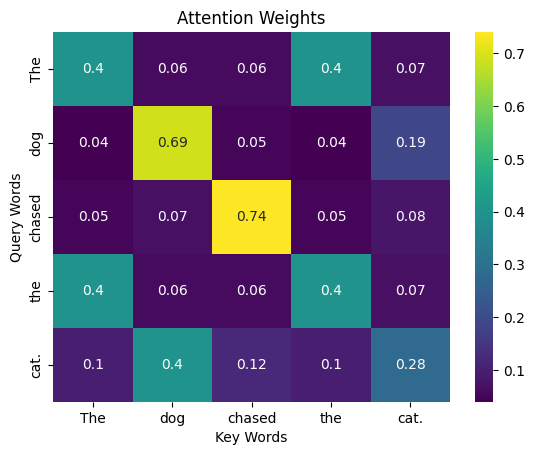

In [59]:
print("Sentence:", sentence)
print("\nAttention Weights:\n", np.round(attn_weights, 2))

import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(attn_weights, annot=True, xticklabels=sentence, yticklabels=sentence, cmap="viridis")
plt.title("Attention Weights")
plt.xlabel("Key Words")
plt.ylabel("Query Words")
plt.show()

In [47]:
! pip install transformers
! pip install huggingface_hub[hf_xet]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 82.8 MB/s eta 0:00:00


In [69]:
from transformers import AutoTokenizer, AutoModel
import torch

sentence = "the dog chased the cat"
tokens = sentence.lower().split()

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
model = AutoModel.from_pretrained("bert-base-uncased")

inputs = tokenizer(tokens, return_tensors="pt", is_split_into_words=True)
with torch.no_grad():
    outputs = model(**inputs)

embeddings = outputs.last_hidden_state[0].numpy()[:len(tokens)]


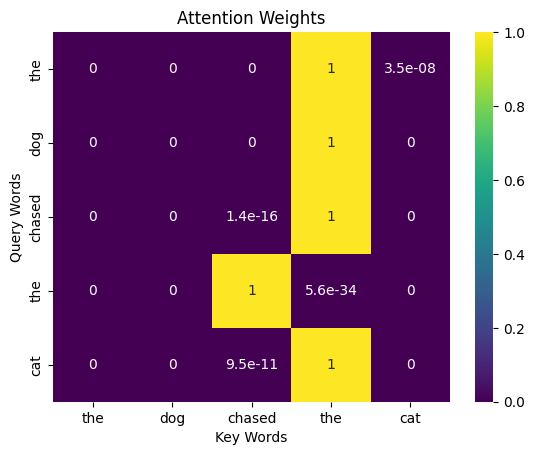

In [70]:

sns.heatmap(attn_weights, annot=True, xticklabels=tokens, yticklabels=tokens, cmap="viridis")
plt.title("Attention Weights")
plt.xlabel("Key Words")
plt.ylabel("Query Words")
plt.show()

### How does it actually happen?

In [71]:
def scaled_dot_product_attention(Q, K, V):
    d_k = Q.shape[-1]
    scores = torch.matmul(Q, K.transpose(0, 1)) / torch.sqrt(torch.tensor(d_k, dtype=torch.float32))
    attn_weights = torch.softmax(scores, dim=-1)
    return attn_weights


In [72]:
embeddings = torch.from_numpy(embeddings)
d_model = embeddings.shape[-1] # 768 for BERT
d_k = 32

# Random projection weights
W_q = torch.randn(d_model, d_k)
W_k = torch.randn(d_model, d_k)
W_v = torch.randn(d_model, d_k)

# Project into Q, K, V
Q = embeddings @ W_q  # shape: (n, d_k)
K = embeddings @ W_k
V = embeddings @ W_v

In [76]:
attn_weights = scaled_dot_product_attention(Q, K, V)

print("Key vector shape:", K.shape) # 5 tokens with 32
print("Query vector shape:", Q.shape)
print("Value vector shape:", V.shape)
print("Attention weights shape:", attn_weights.shape)

Key vector shape: torch.Size([5, 32])
Query vector shape: torch.Size([5, 32])
Value vector shape: torch.Size([5, 32])
Attention weights shape: torch.Size([5, 5])


In [77]:
output = torch.matmul(attn_weights, V) # updated values? with meaningful contributions
print("Final output shape:", output.shape)
print("Final output:", output[0])

Final output shape: torch.Size([5, 32])
Final output: tensor([  5.0406,   0.6493,  -3.1640,  -3.5897,  -2.6178,  -5.4739,  -8.7486,
        -12.9132,   1.7439,  12.8213, -29.5461, -26.5891,  -4.8239,  25.6276,
          5.1998,  21.4095,  -6.4021,   6.1938,  -1.5171,   2.0568,  21.3888,
         -4.0424,   2.7886, -27.1430,  -4.2866, -31.4521,   1.8210,   0.7053,
         -8.2492,  -2.0968,  10.9642,   4.0817])


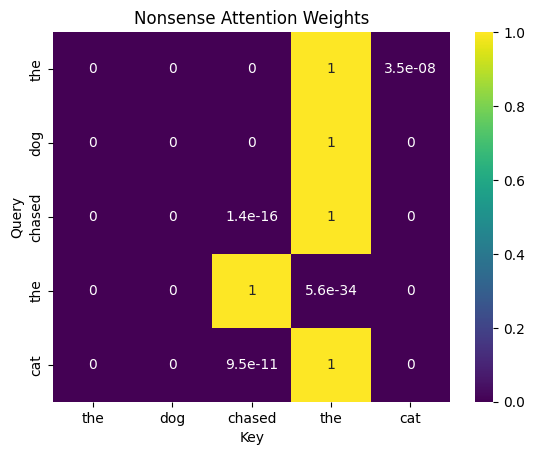

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(attn_weights.detach().numpy(), xticklabels=tokens, yticklabels=tokens, annot=True, cmap="viridis")
plt.title("Nonsense Attention Weights")
plt.xlabel("Key")
plt.ylabel("Query")
plt.show()
